# CSE 579 Homework 3: Model-Based Reinforcement Learning

In this assignment, you will implement:
1. **Random MPC with shooting** on a learned dynamics model
2. **Model Predictive Path Integral (MPPI)** control
3. **Ensemble MPPI** with multiple dynamics models for uncertainty

You will train and evaluate on **Reacher-v4**.


**Getting started:** Click **File > Save a copy in Drive** to create your own editable copy of this notebook. Do not edit the original.


## 1. Setup and Installation


In [66]:
# Clone the homework repository
!git clone https://github.com/WEIRDLabUW/CSE579-hw3.git
!cp -r CSE579-hw3/* .
!cp -r CSE579-hw3/.gitignore .


fatal: destination path 'CSE579-hw3' already exists and is not an empty directory.


In [ ]:
# Install system dependencies (for MuJoCo rendering)
!apt-get install -y \
    libgl1-mesa-dev \
    libgl1-mesa-glx \
    libglew-dev \
    libosmesa6-dev \
    software-properties-common \
    patchelf

# Install PyTorch with CUDA support
!pip install -q \
    torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 \
    --extra-index-url https://download.pytorch.org/whl/cu124

# Install gymnasium + mujoco + imageio.
# (We do not need gymnasium-robotics — it pins mujoco<3.0, which lacks prebuilt
# wheels for Colab's Python and forces a source build that fails.)
!pip install -q \
    gymnasium==0.29.1 \
    mujoco \
    "imageio[ffmpeg]" \
    matplotlib \
    "numpy>=1.24,<2.0" \
    tqdm

import os
os.environ['LD_PRELOAD'] = ':/usr/lib/x86_64-linux-gnu/libGLEW.so'

# Restart the runtime so the new numpy version takes effect.
# After restart, skip this cell and continue from the next one.
os.kill(os.getpid(), 9)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libglew-dev is already the newest version (2.2.0-4).
patchelf is already the newest version (0.14.3-1).
libgl1-mesa-dev is already the newest version (23.2.1-1ubuntu3.1~22.04.3).
libosmesa6-dev is already the newest version (23.2.1-1ubuntu3.1~22.04.3).
software-properties-common is already the newest version (0.99.22.9).
libgl1-mesa-glx is already the newest version (23.0.4-0ubuntu1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


**Important:** The cell above restarts the runtime. After it restarts, skip cells 1 & 2 above and continue from the cell below.


In [13]:
# Re-set env vars (lost after runtime restart)
import os
os.environ['LD_PRELOAD'] = ':/usr/lib/x86_64-linux-gnu/libGLEW.so'
os.environ['MUJOCO_GL'] = 'egl'


## 2. Imports and Device Setup


In [14]:
import copy
import math
import random

import gymnasium as gym
import numpy as np
import torch
import torch.optim as optim

from utils import DeterministicDynamicsModel, ReplayBuffer, reward_fn_reacher, set_random_seed
from rollouts import evaluate
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using device:', device)


using device: cuda


## 3. Planning (`planning.py`)

Fill in the TODOs below. You will implement (in order):
1. `rollout_model` — autoregressive rollout under the learned dynamics model.
2. `plan_model_random_shooting` — random MPC.
3. The MPPI iteration body inside `plan_model_mppi`.
4. (For Part 4) `get_ensemble_rewards` and the ensemble branches inside `plan_model_mppi`.


In [15]:
def rollout_model(
        model,
        initial_states,
        actions,
        horizon,
        reward_fn):
    # Collect the following data
    all_states = []
    all_rewards = []
    curr_state = initial_states # Starting from the initial state
    #========== TODO: start ==========
    # Hint1: concatenate current state and action pairs as the input for the model and predict the next observation
    # for horizon number of steps
    # Hint2: get the predicted reward using reward_fn()

    for step_num in range(horizon):

      # Concatenate current state and action pairs as the input
      cur_ac = actions[:, step_num, :] # (n_samples, ac_size)

      if not isinstance(curr_state, torch.Tensor):
        curr_state = torch.from_numpy(curr_state).to(device).float()
      else:
        curr_state = curr_state.clone().detach().to(device).float()

      input = torch.cat([curr_state, cur_ac], dim=-1)

      # Predicts the next observation
      next_obs = model(input)

      # Gets the predicted reward
      predicted_reward = reward_fn(next_obs, cur_ac)

      all_states.append(next_obs)
      all_rewards.append(predicted_reward)
      curr_state = next_obs

    #========== TODO: end ==========
    all_states_full = torch.cat([state[:, None, :] for state in all_states], dim=1).cpu().detach().numpy()
    all_rewards_full = torch.cat(all_rewards, dim=-1).cpu().detach().numpy()
    return all_states_full, all_rewards_full


def get_ensemble_rewards(model, state_repeats, random_actions, horizon, reward_fn):
    """This method will generate the average reward rolled out over the ensemble of models

    Args:
        model List: The list of models
        state_repeats: The initial state repeated over the num random action sequence dimension
        random_actions: The random actions to be taken
        horizon: How long to roll out the model
        reward_fn: Used to get the reward
    """
    #========== TODO: start ==========
    # For each model in the list of models, rollout the model and get the rewards using the rollout_model
    # function. Take the mean of the rewards over each time step to get the average reward to return for
    # the passed action sequence. The output should be an array of the length of the number of random actions

    n_samples = random_actions.shape[0]
    all_rewards = torch.zeros((n_samples, horizon), device=device)
    for m in model:
      states, rewards = rollout_model(m, state_repeats, random_actions, horizon, reward_fn)

      if not isinstance(rewards, torch.Tensor):
        rewards = torch.from_numpy(rewards).to(device).float()
      else:
        rewards = rewards.clone().detach().to(device).float()

      all_rewards += rewards

    all_rewards /= len(model) # Average over the models

    #========== TODO: end ==========
    return all_rewards


def plan_model_random_shooting(env, state, ac_size, horizon, model, reward_fn, n_samples_mpc=100):
    #========== TODO: start ==========
    # Hint1: randomly sample actions in the action space
    # Hint2: rollout model based on current state and random action using the rollout_model function.
    # Then select the best action that maximize the sum of the reward

    # Note: I was struggling with tensor/numpy stuff but then I saw that plan_model_mppi basically has the solution

    state_repeats = torch.from_numpy(np.repeat(state[None], n_samples_mpc, axis=0)).to(device)

    # Samples uniformly in action space
    random_actions = torch.FloatTensor(n_samples_mpc, horizon, ac_size).uniform_(env.action_space.low[0], env.action_space.high[0]).to(device).float()

    # Rolling forward through the mdoel for horizon steps
    all_states, all_rewards = rollout_model(model, state_repeats, random_actions, horizon, reward_fn)

    best_ac_idx = np.argmax(all_rewards.sum(axis=-1))
    best_ac = random_actions[best_ac_idx, 0] # Take the first action from the best trajectory

    #========== TODO: end ==========
    return best_ac, random_actions[best_ac_idx]


def plan_model_mppi(env, state, ac_size, horizon, model, reward_fn, n_samples_mpc=100, n_iter_mppi=10, gaussian_noise_scales=[1.0, 1.0, 0.5, 0.5, 0.2, 0.2, 0.1, 0.1, 0.01, 0.01]):
    assert len(gaussian_noise_scales) == n_iter_mppi
    # Rolling forward random actions through the model
    state_repeats = torch.from_numpy(np.repeat(state[None], n_samples_mpc, axis=0)).to(device)
    # Sampling random actions in the range of the action space
    random_actions = torch.FloatTensor(n_samples_mpc, horizon, ac_size).uniform_(env.action_space.low[0], env.action_space.high[0]).to(device).float()
    # Rolling forward through the mdoel for horizon steps
    if not isinstance(model, list):
        all_states, all_rewards = rollout_model(model, state_repeats, random_actions, horizon, reward_fn)
        # all_rewards (n_samples_mpc, horizon)
        all_returns = all_rewards.sum(axis=-1) # (n_samples_mpc,)
    else:
        # NOTE: Implement this branch in part 4 of the writeup, not in part 3. This is for the ensemble model
        # Use the get_ensemble_rewards function to get the rewards for the ensemble model
        all_rewards = get_ensemble_rewards(model, state_repeats, random_actions, horizon, reward_fn) # (n_samples_mpc, horizon)
        all_returns = torch.mean(all_rewards, dim=1) # (n_samples, mpc)

    # Take first action from best trajectory
    best_ac_idx = all_returns.argmax().item()
    best_ac = random_actions[best_ac_idx, 0] # Take the first action from the best trajectory

    # Run through a few iterations of MPPI

    for iter in range(n_iter_mppi):
        #========== TODO: start ==========
        # Hint1: Compute weights based on exponential of returns
        # Hint2: sample actions based on the weight, and compute average return over models
        # Hint3: if model type is a list, then implement ensemble mppi
        # Hint4: Refer to the psudeocode in the writeup for more details

        # Weight trajectories by exponential of returns

        # all_returns is of shape (n_samples_mpc,), each entry is sum of returns
        if not isinstance(all_returns, torch.Tensor):
            all_returns = torch.from_numpy(all_returns).to(device).float()
        else:
            all_returns = all_returns.to(device).float()
        exp_returns = torch.exp(all_returns - all_returns.max()) # subtract x - np.max(x) to prevent overflow
        weights = exp_returns / torch.sum(exp_returns)

        # Compute weighted sum of actions

        # Broadcast weights along the (horizon, ac_size), may need to double check this
        weights = weights.view(weights.shape[0], 1, 1)
        weighted_sum = torch.sum(random_actions * weights, dim=0) # (horizon, ac_size)

        # Compute mean and std of the best trajectories
        action_mean = weighted_sum.to(device)
        action_std = (torch.ones(weighted_sum.shape) * gaussian_noise_scales[iter]).to(device).view(horizon, ac_size)

        # Sample new actions
        random_actions = torch.randn(n_samples_mpc, horizon, ac_size, device=device).float() * action_std + action_mean

        # Rolling forward through the model for horizon steps (or ensemble) to update the rewards
        if not isinstance(model, list):
            # Rolling forward through the mdoel for horizon steps
            all_states, all_rewards = rollout_model(model, state_repeats, random_actions, horizon, reward_fn)
            all_returns = all_rewards.sum(axis=-1)
        else:
            # NOTE: Implement this branch in part 4 of the writeup, not in part 3. This is for the ensemble model.
            # Use the get_ensemble_rewards function to get the rewards for the ensemble model
            all_rewards = get_ensemble_rewards(model, state_repeats, random_actions, horizon, reward_fn) # (n_samples_mpc, horizon)
            all_returns = torch.mean(all_rewards, dim=1) # (n_samples, mpc)
        #========== TODO: end ==========

    # Finally take first action from best trajectory
    best_ac_idx = all_returns.argmax().item()
    best_ac = random_actions[best_ac_idx, 0] # Take the first action from the best trajectory
    return best_ac, random_actions[best_ac_idx]


## 4. Model Training (`train_model.py`)

Fill in the TODO inside `train_model` to support the ensemble case (Part 4). Each model in the ensemble should be trained with a different batch size to improve diversity.


In [16]:
loss_fn = torch.nn.MSELoss()

def train_single(num_epochs, num_batches,batch_size, model, optimizer, replay_buffer):
    for epoch in range(num_epochs):

        for i in range(num_batches):
            optimizer.zero_grad()
            t1_observations, t1_actions, _, t1_next_observations, _ = replay_buffer.sample(batch_size)
            oa_in = torch.cat([t1_observations, t1_actions], dim=-1)

            next_o_pred = model(oa_in)
            loss = loss_fn(next_o_pred, t1_next_observations)

            loss.backward()
            optimizer.step()


def train_model(model, replay_buffer, optimizer, num_epochs=500, batch_size=32):
    """
    Train a single model with supervised learning
    """
    idxs = np.array(range(len(replay_buffer)))
    num_batches = len(idxs) // batch_size
    if not isinstance(model, list):
        train_single(num_epochs, num_batches, batch_size, model, optimizer, replay_buffer)
    else:
        #========== TODO: start ==========
        # Write code to train the ensemble of models.
        # Hint1: Each model should have a different batch size for each model
        # Hint2: check out how we define optimizer and model for ensemble models.
        # During training, each model should have their individual optimizer to increase diversity.
        # Hint3: You can use the train_single function to train each model.

        for i in range(len(model)):
          m, opt = model[i], optimizer[i]
          batch_size = np.random.randint(250, 501) # Random range [250, 500]
          train_single(num_epochs, num_batches, batch_size, m, opt, replay_buffer)
        #========== TODO: end ==========


## 5. Helpers (do not modify)


In [17]:
def planning_agent(env, o_for_agent, model, reward_fn, plan_mode, mpc_horizon=None, n_samples_mpc=None):
    if plan_mode == 'random':
        action = torch.Tensor(env.action_space.sample()[None]).to(device)
    elif plan_mode == 'random_mpc':
        action, _ = plan_model_random_shooting(env, o_for_agent, env.action_space.shape[0], mpc_horizon, model,
                                               reward_fn, n_samples_mpc=n_samples_mpc)
    elif plan_mode == 'mppi':
        action, _ = plan_model_mppi(env, o_for_agent, env.action_space.shape[0], mpc_horizon, model, reward_fn,
                                    n_samples_mpc=n_samples_mpc)
    else:
        raise NotImplementedError("Other planning methods not implemented")
    return action


def collect_traj_MBRL(env, model, plan_mode, replay_buffer=None, device=device,
                     episode_length=math.inf, reward_fn=None, render=False,
                     mpc_horizon=None, n_samples_mpc=None):
    raw_obs, raw_next_obs, actions, rewards, dones, images = [], [], [], [], [], []
    path_length = 0
    o, _ = env.reset()
    with torch.no_grad():
        while path_length < episode_length:
            action = planning_agent(env, o, model, reward_fn, plan_mode,
                                    mpc_horizon=mpc_horizon, n_samples_mpc=n_samples_mpc)
            if len(action.shape) == 1:
                action = action.unsqueeze(0)
            action = action.cpu().detach().numpy()[0]
            next_o, r, done, trunc, _ = env.step(copy.deepcopy(action))
            done = done or trunc
            if replay_buffer is not None:
                replay_buffer.add(o, action, r, next_o, done)
            raw_obs.append(o); raw_next_obs.append(next_o)
            actions.append(action); rewards.append(r); dones.append(done)
            path_length += 1
            if done:
                break
            o = next_o

    observations = np.array(raw_obs); next_observations = np.array(raw_next_obs)
    actions = np.array(actions)
    if len(actions.shape) == 1:
        actions = np.expand_dims(actions, 1)
    rewards = np.array(rewards)
    if len(rewards.shape) == 1:
        rewards = rewards.reshape(-1, 1)
    dones = np.array(dones).reshape(-1, 1)
    return dict(observations=observations, next_observations=next_observations,
                actions=actions, rewards=rewards, dones=dones, images=np.array(images))


def simulate_mbrl(env, model, plan_mode, num_epochs=200, max_path_length=200, mpc_horizon=10,
                  n_samples_mpc=200, batch_size=100, num_agent_train_epochs_per_iter=1000,
                  capacity=100000, num_traj_per_iter=100, gamma=0.99, print_freq=10,
                  device="cuda", reward_fn=None):
    if not isinstance(model, list):
        optimizer = optim.Adam(model.parameters(), lr=1e-4)
    else:
        print('Initialize separate optimizers for ensemble mbrl')
        optimizer = [optim.Adam(m.parameters(), lr=(i+1)*1e-4) for i, m in enumerate(model)]

    replay_buffer = ReplayBuffer(obs_size=env.observation_space.shape[0],
                                 action_size=env.action_space.shape[0],
                                 capacity=capacity, device=device)

    rewards = []
    epochs = []

    for iter_num in range(num_epochs):
        sample_trajs = []
        seed_mode = 'random' if iter_num == 0 else plan_mode
        for _ in range(num_traj_per_iter):
            sample_trajs.append(collect_traj_MBRL(
                env=env, model=model, plan_mode=seed_mode, replay_buffer=replay_buffer,
                device=device, episode_length=max_path_length, reward_fn=reward_fn, render=False,
                mpc_horizon=None if iter_num == 0 else mpc_horizon,
                n_samples_mpc=None if iter_num == 0 else n_samples_mpc))

        train_model(model, replay_buffer, optimizer,
                    num_epochs=num_agent_train_epochs_per_iter, batch_size=batch_size)

        if iter_num % print_freq == 0:
            r = np.mean([t['rewards'].sum() for t in sample_trajs])
            L = np.max([t['rewards'].shape[0] for t in sample_trajs])
            print(f"Episode: {iter_num}, reward: {r}, max path length: {L}")

        epochs.append(iter_num)
        rewards.append(r)

    return rewards, epochs


---


## 6. Train and Evaluate


In [18]:
import planning
import rollouts

# 1. Import the module AND the function explicitly under distinct names
import train_model as train_model_module
from train_model import train_model as original_train_model_fn

# Patch the function in the planning module's namespace
planning.rollout_model = rollout_model
planning.get_ensemble_rewards = get_ensemble_rewards
planning.plan_model_random_shooting = plan_model_random_shooting
planning.plan_model_mppi = plan_model_mppi

# 2. Correctly patch the function inside the imported module's namespace
train_model_module.train_model = train_model  # Patches it with your newly defined local train_model function below

# ALSO patch rollouts, since it imported planning_agent which closes over planning's namespace
import importlib
importlib.reload(rollouts)

<module 'rollouts' from '/content/rollouts.py'>

In [19]:
class Args:
    def __init__(self, model_type, plan_mode, test=False, render=False, seed=0):
        self.model_type = model_type  # 'single' or 'ensemble'
        self.plan_mode = plan_mode    # 'random_mpc' or 'mppi'
        self.test = test
        self.render = render
        self.seed = seed


def train_and_eval(args):
    """Train (or load) one (model_type, plan_mode) config, then evaluate."""
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed_all(args.seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    random.seed(args.seed)
    np.random.seed(args.seed)
    set_random_seed(args.seed)

    env = gym.make("Reacher-v4")
    env.reset(seed=args.seed)
    env.action_space.seed(args.seed)
    max_path_length = 50

    hidden_dim_model = 64
    hidden_depth_model = 2
    obs_dim = env.observation_space.shape[0]
    ac_dim = env.action_space.shape[0]
    if args.model_type == 'single':
        model = DeterministicDynamicsModel(obs_dim + ac_dim, obs_dim,
                                           hidden_dim=hidden_dim_model,
                                           hidden_depth=hidden_depth_model).to(device)
    else:
        model = [DeterministicDynamicsModel(obs_dim + ac_dim, obs_dim,
                                            hidden_dim=hidden_dim_model,
                                            hidden_depth=hidden_depth_model).to(device)
                 for _ in range(5)]

    num_epochs = 15
    batch_size = 250
    num_agent_train_epochs_per_iter = 10
    num_traj_per_iter = batch_size // max_path_length
    capacity = 100000
    mpc_horizon = 10
    n_samples_mpc = 1000

    if not args.test:
        rewards, epochs = simulate_mbrl(env, model, plan_mode=args.plan_mode, num_epochs=num_epochs,
                      max_path_length=max_path_length, mpc_horizon=mpc_horizon,
                      n_samples_mpc=n_samples_mpc, batch_size=batch_size,
                      num_agent_train_epochs_per_iter=num_agent_train_epochs_per_iter,
                      capacity=capacity, num_traj_per_iter=num_traj_per_iter,
                      gamma=0.99, print_freq=1, device=device, reward_fn=reward_fn_reacher)

        plt.plot(epochs, rewards)
        plt.title(f"Average Reward during Training for {args.model_type.capitalize()} on {args.plan_mode.capitalize()}")
        plt.xlabel("Epoch")
        plt.ylabel("Average Reward")

        if isinstance(model, list):
            for i, m in enumerate(model):
                torch.save(m.state_dict(), f'{args.model_type}_{args.plan_mode}_final_{i}.pth')
        else:
            torch.save(model.state_dict(), f'{args.model_type}_{args.plan_mode}_final.pth')
    else:
        if isinstance(model, list):
            for i in range(len(model)):
                model[i].load_state_dict(torch.load(
                    f'{args.model_type}_{args.plan_mode}_final_{i}.pth', map_location=device))
        else:
            model.load_state_dict(torch.load(
                f'{args.model_type}_{args.plan_mode}_final.pth', map_location=device))

    evaluate(env, model, plan_mode=args.plan_mode, mpc_horizon=mpc_horizon,
             n_samples_mpc=n_samples_mpc, num_validation_runs=100,
             episode_length=max_path_length, render=args.render, reward_fn=reward_fn_reacher)
    return model


### 6a. Random MPC — Single Model


Episode: 0, reward: -42.03357272477837, max path length: 50
Episode: 1, reward: -23.352428236860966, max path length: 50
Episode: 2, reward: -27.16534568625874, max path length: 50
Episode: 3, reward: -25.462548848323628, max path length: 50
Episode: 4, reward: -24.617414487752093, max path length: 50
Episode: 5, reward: -21.797218915199654, max path length: 50
Episode: 6, reward: -21.568047358710665, max path length: 50
Episode: 7, reward: -20.714236054797283, max path length: 50
Episode: 8, reward: -19.25969814518222, max path length: 50
Episode: 9, reward: -22.059020874509862, max path length: 50
Episode: 10, reward: -21.788996893051785, max path length: 50
Episode: 11, reward: -24.64236757038068, max path length: 50
Episode: 12, reward: -18.71250519813399, max path length: 50
Episode: 13, reward: -22.792457437623735, max path length: 50
Episode: 14, reward: -20.22916617820173, max path length: 50
test 0, success True, reward -17.38156922976242
test 1, success False, reward -25.7006

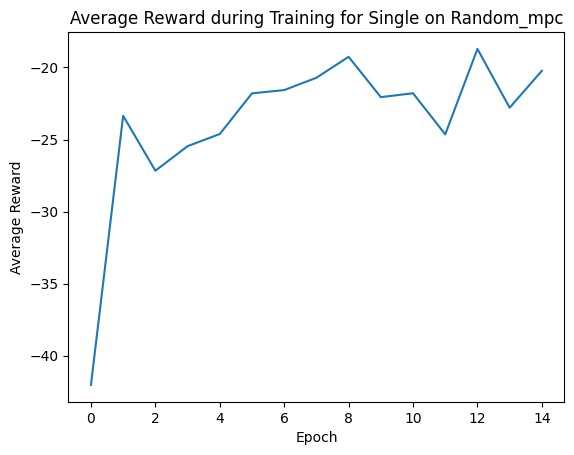

In [20]:
args = Args('single', 'random_mpc')
result = train_and_eval(args)


### 6b. MPPI — Single Model


Episode: 0, reward: -42.03357272477837, max path length: 50
Episode: 1, reward: -9.444863730112775, max path length: 50
Episode: 2, reward: -11.73321111876275, max path length: 50
Episode: 3, reward: -12.227966028762262, max path length: 50
Episode: 4, reward: -8.21531038958504, max path length: 50
Episode: 5, reward: -9.89129024492299, max path length: 50
Episode: 6, reward: -7.519163003208985, max path length: 50
Episode: 7, reward: -7.219451253348611, max path length: 50
Episode: 8, reward: -6.921878734569876, max path length: 50
Episode: 9, reward: -7.578212436400821, max path length: 50
Episode: 10, reward: -9.174256491152736, max path length: 50
Episode: 11, reward: -8.93765096635041, max path length: 50
Episode: 12, reward: -5.6535091571012, max path length: 50
Episode: 13, reward: -6.42049831357175, max path length: 50
Episode: 14, reward: -5.225395753414665, max path length: 50
test 0, success True, reward -4.711572698757483
test 1, success True, reward -2.767021713913882
test

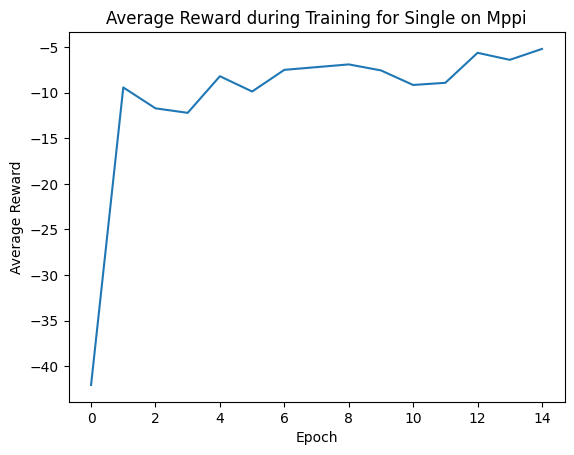

In [21]:
args = Args('single', 'mppi')
result = train_and_eval(args)


### 6c. Ensemble MPPI


Initialize separate optimizers for ensemble mbrl
Episode: 0, reward: -42.03357272477837, max path length: 50
Episode: 1, reward: -11.003248236214215, max path length: 50
Episode: 2, reward: -11.997611597422926, max path length: 50
Episode: 3, reward: -11.421837654958717, max path length: 50
Episode: 4, reward: -10.170762684299849, max path length: 50
Episode: 5, reward: -10.104766069591069, max path length: 50
Episode: 6, reward: -7.763261029283013, max path length: 50
Episode: 7, reward: -8.009827196011933, max path length: 50
Episode: 8, reward: -8.025328042751699, max path length: 50
Episode: 9, reward: -8.833178934784588, max path length: 50
Episode: 10, reward: -12.280017999838744, max path length: 50
Episode: 11, reward: -11.878985592151666, max path length: 50
Episode: 12, reward: -7.868968595439073, max path length: 50
Episode: 13, reward: -7.034834856020953, max path length: 50
Episode: 14, reward: -6.308251647022519, max path length: 50
test 0, success True, reward -5.9254793

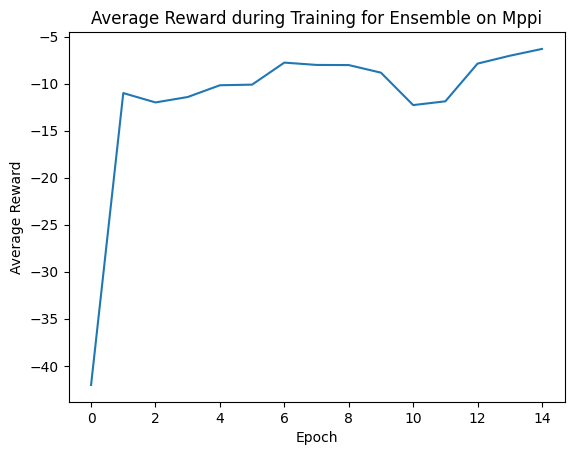

In [22]:
args = Args('ensemble', 'mppi')
result = train_and_eval(args)


---
## Submission

Download the trained `.pth` weights below and submit them along with your filled-in `planning.py` and `train_model.py` (or this notebook).


In [11]:
import glob

# If running on Google Colab, trigger download of weight files
try:
    from google.colab import files
    for f in glob.glob("*.pth"):
        files.download(f)
except ImportError:
    print("Not on Colab. Weights are saved in the current directory:")
    for f in glob.glob("*.pth"):
        print(" ", f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>